# Mạng Nơ-ron Tích chập (CNN): Ứng dụng

Chào mừng bạn đến với bài tập thứ hai của Khóa học 4! Trong notebook này, bạn sẽ:

- Tạo một bộ phân loại trạng thái cảm xúc (mood classifier) ​​sử dụng Sequential API của TF Keras
- Xây dựng một mạng ConvNet để nhận diện các chữ số trong ngôn ngữ ký hiệu sử dụng Functional API của TF Keras

**Sau bài tập này, bạn sẽ có thể:**

- Xây dựng và huấn luyện một mạng ConvNet trong TensorFlow cho bài toán phân loại __nhị phân__ (binary classification)
- Xây dựng và huấn luyện một mạng ConvNet trong TensorFlow cho bài toán phân loại __đa lớp__ (multiclass classification)
- Giải thích các trường hợp sử dụng khác nhau cho Sequential API và Functional API

Để hoàn thành bài tập này, bạn cần có kiến ​​thức cơ bản về TensorFlow. Nếu chưa nắm vững, vui lòng xem lại **Hướng dẫn về TensorFlow** trong tuần thứ ba của Khóa học 2 ("**Cải thiện mạng nơ-ron sâu**").

## Lưu ý quan trọng về việc nộp bài cho hệ thống chấm điểm tự động (AutoGrader)

Trước khi nộp bài tập cho AutoGrader, hãy đảm bảo bạn không thực hiện các hành động sau:

1. Thêm bất kỳ câu lệnh `print` _nào khác_ vào bài tập.
2. Thêm bất kỳ ô mã (code cell) _nào khác_ vào bài tập.
3. Thay đổi bất kỳ tham số nào của hàm.
4. Sử dụng biến toàn cục (global variable) bên trong các bài tập được chấm điểm. Trừ khi có hướng dẫn cụ thể, hãy tránh sử dụng biến toàn cục và thay vào đó hãy sử dụng biến cục bộ (local variable).
5. Thay đổi mã nguồn của bài tập ở những phần không yêu cầu, chẳng hạn như tạo thêm các biến _không cần thiết_.

Nếu thực hiện các hành động trên, bạn có thể gặp lỗi như `Grader not found` (hoặc các lỗi bất thường tương tự) khi nộp bài. Trước khi tìm kiếm sự trợ giúp hoặc gỡ lỗi (debug), hãy kiểm tra các vấn đề này trước tiên. Nếu gặp lỗi do các thay đổi này và bạn không nhớ mình đã sửa những gì, bạn có thể lấy lại bản sao mới của bài tập bằng cách làm theo các [hướng dẫn này](https://www.coursera.org/learn/convolutional-neural-networks/supplement/DS4yP/h-ow-to-refresh-your-workspace).

## Table of Contents

- [1 - Packages](#1)
    - [1.1 - Load the Data and Split the Data into Train/Test Sets](#1-1)
- [2 - Layers in TF Keras](#2)
- [3 - The Sequential API](#3)
    - [3.1 - Create the Sequential Model](#3-1)
        - [Exercise 1 - happyModel](#ex-1)
    - [3.2 - Train and Evaluate the Model](#3-2)
- [4 - The Functional API](#4)
    - [4.1 - Load the SIGNS Dataset](#4-1)
    - [4.2 - Split the Data into Train/Test Sets](#4-2)
    - [4.3 - Forward Propagation](#4-3)
        - [Exercise 2 - convolutional_model](#ex-2)
    - [4.4 - Train the Model](#4-4)
- [5 - History Object](#5)
- [6 - Bibliography](#6)

<a name='1'></a>
## 1 - Packages

As usual, begin by loading in the packages.

In [30]:
import math
import numpy as np
import h5py
import matplotlib.pyplot as plt
from matplotlib.pyplot import imread
import scipy
from PIL import Image
import pandas as pd
import tensorflow as tf
import tensorflow.keras.layers as tfl
from tensorflow.python.framework import ops
from cnn_utils import *
from test_utils import summary, comparator

%matplotlib inline
np.random.seed(1)

<a name='1-1'></a>
### 1.1 - Tải dữ liệu và chia dữ liệu thành các tập huấn luyện/kiểm tra

Trong phần này của bài tập, bạn sẽ sử dụng bộ dữ liệu "Happy House" (Ngôi nhà Hạnh phúc), bao gồm các hình ảnh khuôn mặt người. Nhiệm vụ của bạn là xây dựng một mạng ConvNet để xác định xem những người trong ảnh có đang mỉm cười hay không — bởi vì họ chỉ được phép vào nhà nếu họ đang mỉm cười!

In [31]:
X_train_orig , Y_train_orig , X_test_orig , Y_test_orig , classes = load_happy_dataset()

#Normalize image vectors
X_train = X_train_orig / 255.
X_test = X_test_orig / 255.

#Reshape
Y_train = Y_train_orig.T
Y_test = Y_test_orig.T

print ("number of training examples = " + str(X_train.shape[0]))
print ("number of test examples = " + str(X_test.shape[0]))
print ("X_train shape: " + str(X_train.shape))
print ("Y_train shape: " + str(Y_train.shape))
print ("X_test shape: " + str(X_test.shape))
print ("Y_test shape: " + str(Y_test.shape))


number of training examples = 600
number of test examples = 150
X_train shape: (600, 64, 64, 3)
Y_train shape: (600, 1)
X_test shape: (150, 64, 64, 3)
Y_test shape: (150, 1)


Bạn có thể hiển thị các hình ảnh có trong tập dữ liệu. Các hình ảnh có kích thước **64x64** pixel và định dạng RGB (3 kênh).

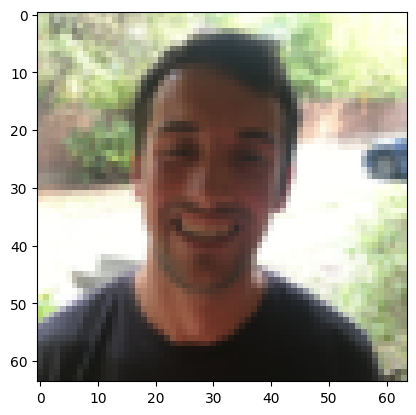

In [32]:
index = 4
plt.imshow(X_train_orig[index])
plt.show()

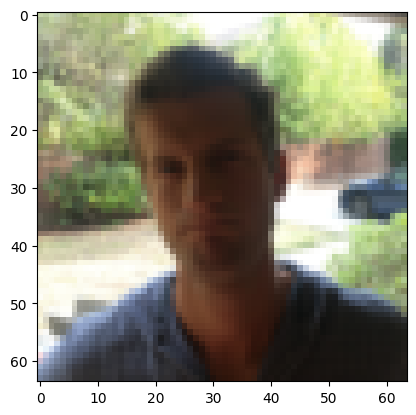

In [33]:
index = 10
plt.imshow(X_train_orig[index])
plt.show()

<a name='2'></a>
## 2 - Các lớp (Layer) trong TF Keras

Trong bài tập trước, bạn đã tự tạo các lớp theo cách thủ công bằng thư viện NumPy. Với TF Keras, bạn không cần phải viết mã trực tiếp để tạo ra các lớp này; thay vào đó, TF Keras cung cấp sẵn các lớp đã được định nghĩa trước để bạn sử dụng.

Khi tạo một lớp trong TF Keras, thực chất bạn đang tạo ra một hàm nhận dữ liệu đầu vào và biến đổi nó thành dữ liệu đầu ra mà bạn có thể tái sử dụng sau này. Thật tiện lợi và dễ dàng!

<a name='3'></a>
## 3 - Sequential API

Trong bài tập trước, bạn đã tự xây dựng các hàm hỗ trợ bằng `numpy` để hiểu cơ chế hoạt động của mạng thần kinh tích chập (CNN). Ngày nay, hầu hết các ứng dụng thực tế của học sâu (deep learning) đều được phát triển dựa trên các framework lập trình; các framework này cung cấp sẵn nhiều hàm chức năng mà bạn có thể gọi trực tiếp để sử dụng. Keras là một thư viện trừu tượng hóa cấp cao được xây dựng trên nền tảng TensorFlow, giúp đơn giản hóa và tối ưu hóa quy trình tạo cũng như huấn luyện mô hình.

Ở phần đầu của bài tập này, bạn sẽ tạo một mô hình sử dụng Sequential API của TF Keras. API này cho phép bạn xây dựng mô hình theo từng lớp một và là lựa chọn lý tưởng cho các mô hình mà mỗi lớp có **đúng một** tensor đầu vào và **một** tensor đầu ra.

Như bạn sẽ thấy, việc sử dụng Sequential API rất đơn giản và trực quan, nhưng nó chỉ phù hợp với các tác vụ đơn giản và có cấu trúc thẳng. Ở phần sau của notebook này, bạn sẽ dành thời gian làm quen với một giải pháp thay thế linh hoạt và mạnh mẽ hơn: Functional API.

<a name='3-1'></a>
### 3.1 - Tạo mô hình Sequential

Như đã đề cập trước đó, Sequential API của TensorFlow Keras có thể được sử dụng để xây dựng các mô hình đơn giản với các thao tác lớp (layer) diễn ra theo trình tự nối tiếp nhau.

Bạn cũng có thể thêm dần các lớp vào mô hình Sequential bằng phương thức `.add()` hoặc loại bỏ chúng bằng phương thức `.pop()`, tương tự như cách thao tác với một danh sách (list) thông thường trong Python.

Thực tế, bạn có thể hình dung mô hình Sequential hoạt động giống như một danh sách các lớp. Giống như danh sách trong Python, các lớp trong mô hình Sequential được sắp xếp theo thứ tự, và thứ tự khai báo chúng là yếu tố quan trọng. Nếu mô hình của bạn có cấu trúc phi tuyến tính hoặc chứa các lớp có nhiều đầu vào hay đầu ra, thì mô hình Sequential sẽ không phải là lựa chọn phù hợp!

Đối với bất kỳ lớp nào được tạo trong Keras, bạn cần xác định trước hình dạng đầu vào (input shape). Lý do là vì trong Keras, hình dạng của các trọng số (weights) phụ thuộc vào hình dạng của dữ liệu đầu vào. Các trọng số chỉ được tạo ra khi mô hình bắt đầu nhận dữ liệu đầu vào. Bạn có thể tạo mô hình Sequential bằng cách truyền một danh sách các lớp vào hàm khởi tạo `Sequential`, giống như cách bạn sẽ thực hiện trong bài tập tiếp theo.

<a name='ex-1'></a>
### Bài tập 1 - happyModel

Hãy triển khai hàm `happyModel` dưới đây để xây dựng mô hình sau: `ZEROPAD2D -> CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> FLATTEN -> DENSE`. Hãy tham khảo [tf.keras.layers](https://www.tensorflow.org/api_docs/python/tf/keras/layers)

Đồng thời, thiết lập các tham số sau cho từng bước:

- [ZeroPadding2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/ZeroPadding2D): padding = 3, input shape = 64 x 64 x 3
- [Conv2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Conv2D): Sử dụng 32 bộ lọc (filter) kích thước 7x7, stride = 1
- [BatchNormalization](https://www.tensorflow.org/api_docs/python/tf/keras/layers/BatchNormalization): áp dụng cho trục (axis) 3
- [ReLU](https://www.tensorflow.org/api_docs/python/tf/keras/layers/ReLU)
- [MaxPool2D](https://www.tensorflow.org/api_docs/python/tf/keras/layers/MaxPool2D): Sử dụng các tham số mặc định
- [Flatten](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Flatten) đầu ra của bước trước đó. 
- Lớp kết nối đầy đủ ([Dense](https://www.tensorflow.org/api_docs/python/tf/keras/layers/Dense)): Sử dụng một lớp kết nối đầy đủ với 1 nơ-ron và hàm kích hoạt sigmoid. 


**Gợi ý:**

Sử dụng **tfl** làm tên viết tắt cho **tensorflow.keras.layers**

In [34]:
def happyModel():
    """
    Triển khai quá trình lan truyền tiến (forward propagation) cho mô hình phân loại nhị phân:
    ZEROPAD2D -> CONV2D -> BATCHNORM -> RELU -> MAXPOOL -> FLATTEN -> DENSE
    """
    model = tf.keras.Sequential([
        # ZeroPadding2D với padding 3, input đầu vào có shape 64 x 64 x 3
        tfl.ZeroPadding2D(padding=(3, 3), input_shape=(64, 64, 3)),
        # Conv2D với 32 bộ lọc (filters/kernels), 7x7 filter, s = 1
        tfl.Conv2D(32, (7, 7)),
        # BatchNormalization theo trục kênh (axis=-1)
        tfl.BatchNormalization(axis=-1),
        # ReLU
        tfl.ReLU(),
        # Max Pooling 2D
        tfl.MaxPool2D(),
        # Flatten: Trải phẳng tensor 3 chiều thành vector 1 chiều
        tfl.Flatten(),
        # Dense: Lớp Fully Connected với 1 neuron duy nhất và hàm kích hoạt Sigmoid
        tfl.Dense(1, activation='sigmoid')
    ])
    model.build((None, 64, 64, 3))
    return model    

In [35]:
happy_model = happyModel()
# Khắc phục tương thích Keras 3
for layer in happy_model.layers:
    layer.output_shape = tuple(layer.output.shape)
# Print a summary for each layer
for layer in summary(happy_model):
    print(layer)
    
output = [['ZeroPadding2D', (None, 70, 70, 3), 0, ((3, 3), (3, 3))],
            ['Conv2D', (None, 64, 64, 32), 4736, 'valid', 'linear', 'GlorotUniform'],
            ['BatchNormalization', (None, 64, 64, 32), 128],
            ['ReLU', (None, 64, 64, 32), 0],
            ['MaxPooling2D', (None, 32, 32, 32), 0, (2, 2), (2, 2), 'valid'],
            ['Flatten', (None, 32768), 0],
            ['Dense', (None, 1), 32769, 'sigmoid']]
    
comparator(summary(happy_model), output)

['ZeroPadding2D', (None, 70, 70, 3), 0, ((3, 3), (3, 3))]
['Conv2D', (None, 64, 64, 32), 4736, 'valid', 'linear', 'GlorotUniform']
['BatchNormalization', (None, 64, 64, 32), 128]
['ReLU', (None, 64, 64, 32), 0]
['MaxPooling2D', (None, 32, 32, 32), 0, (2, 2), (2, 2), 'valid']
['Flatten', (None, 32768), 0]
['Dense', (None, 1), 32769, 'sigmoid']
All tests passed!


/root/workspace/.venv/lib/python3.12/site-packages/keras/src/layers/reshaping/zero_padding2d.py:72: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Sau khi đã tạo xong mô hình, bạn có thể biên dịch nó để huấn luyện với bộ tối ưu hóa (optimizer) và hàm mất mát (loss function) tùy chọn. Khi chỉ định chuỗi `accuracy` làm thước đo (metric), loại độ chính xác được sử dụng sẽ tự động được chuyển đổi dựa trên hàm mất mát đã chọn. Đây là một trong nhiều tính năng tối ưu hóa được tích hợp sẵn trong TensorFlow giúp công việc của bạn trở nên dễ dàng hơn! Nếu muốn tìm hiểu thêm về cơ chế hoạt động của quá trình biên dịch, bạn có thể xem tài liệu tại [đây](https://www.tensorflow.org/api_docs/python/tf/keras/Model#compile).

In [36]:
happy_model.compile(optimizer='adam',
                   loss='binary_crossentropy',
                   metrics=['accuracy'])

Đã đến lúc kiểm tra các tham số của mô hình bằng phương thức `.summary()`. Phương thức này sẽ hiển thị các loại lớp, hình dạng của đầu ra và số lượng tham số trong mỗi lớp.

In [37]:
happy_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ zero_padding2d_7                │ (None, 70, 70, 3)      │             0 │
│ (ZeroPadding2D)                 │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 64, 64, 32)     │         4,736 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_7 (ReLU)                  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │        32,769 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 37,633 (147.00 KB)

 Trainable params: 37,569 (146.75 KB)

 Non-trainable params: 64 (256.00 B)

<a name='3-2'></a>
### 3.2 - Huấn luyện và Đánh giá Mô hình

Sau khi tạo mô hình, biên dịch nó với bộ tối ưu hóa (optimizer) và hàm mất mát (loss function) tùy chọn, cũng như kiểm tra sơ bộ cấu trúc của nó, giờ đây bạn đã sẵn sàng để tiến hành huấn luyện!

Chỉ cần gọi phương thức `.fit()` để bắt đầu huấn luyện. Đơn giản vậy thôi! Bạn không cần phải lo về việc chia lô nhỏ (mini-batching), lưu trữ mô hình hay thực hiện các tính toán lan truyền ngược (backpropagation) phức tạp. Mọi công đoạn đó đã được xử lý tự động vì bạn đang sử dụng tập dữ liệu TensorFlow đã được định nghĩa sẵn các lô (batch). Tuy nhiên, bạn vẫn có thể tùy ý chỉ định số lượng epoch hoặc kích thước lô nhỏ nếu muốn (ví dụ: trong trường hợp sử dụng tập dữ liệu chưa được chia lô).

In [38]:
import tensorflow as tf

gpus = tf.config.list_physical_devices("GPU")

if gpus:
    tf.config.experimental.set_memory_growth(gpus[0], True)

print("GPU:", gpus)

RuntimeError: Physical devices cannot be modified after being initialized

In [ ]:
with tf.device("/GPU:0"):
    history = happy_model.fit(
        X_train,
        Y_train,
        epochs=10,
        batch_size=1
    )

Epoch 1/10


E0000 00:00:1791453786.570430 1610544 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
E0000 00:00:1791453786.585878 1610544 cuda_dnn.cc:454] Loaded runtime CuDNN library: 9.1.0 but source was compiled with: 9.3.0.  CuDNN library needs to have matching major version and equal or higher minor version. If using a binary install, upgrade your CuDNN library.  If building from sources, make sure the library loaded at runtime is compatible with the version specified during compile configuration.
W0000 00:00:1791453786.589232 1610544 op_kernel.cc:1858] OP_REQUIRES failed at xla_ops.cc:602 : FAILED_PRECONDITION: DNN library initialization failed. Look at the errors above for mor

FailedPreconditionError: Graph execution error:

Detected at node StatefulPartitionedCall defined at (most recent call last):
  File "<frozen runpy>", line 198, in _run_module_as_main

  File "<frozen runpy>", line 88, in _run_code

  File "/root/workspace/.venv/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>

  File "/root/workspace/.venv/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance

  File "/root/workspace/.venv/lib/python3.12/site-packages/ipykernel/kernelapp.py", line 807, in start

  File "/root/workspace/.venv/lib/python3.12/site-packages/tornado/platform/asyncio.py", line 211, in start

  File "/root/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py", line 645, in run_forever

  File "/root/.local/share/uv/python/cpython-3.12.12-linux-x86_64-gnu/lib/python3.12/asyncio/base_events.py", line 1999, in _run_once

  File "/root/.local/share/uv/python/cpython-3.12.12-l